In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.integrate import trapezoid
from scipy.stats import linregress

from amocatlas import read
from correlation_trends import geostrophy, filters, analysis, correlation, seasonal, trends

In [4]:
figpath = "../figures/"

In [5]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# MOC = transports.MOC
TRANS_FC = transports.MOC
TRANS_EKMAN = transports.TRANS_EKMAN
# TRANS_UMO = transports.TRANS_UMO

# 47N NOAC overturning (monthly): MOC_SIGMA0
# noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [6]:
detrended_FC = analysis.detrending(TRANS_FC, TRANS_FC["TIME"])
detrended_EKMAN = analysis.detrending(TRANS_EKMAN, TRANS_FC["TIME"])
deseasonalized_FC = seasonal.remove_seasonal_cycle(detrended_FC)
deseasonalized_EKMAN = seasonal.remove_seasonal_cycle(detrended_EKMAN)

(0.0, 2000.0)

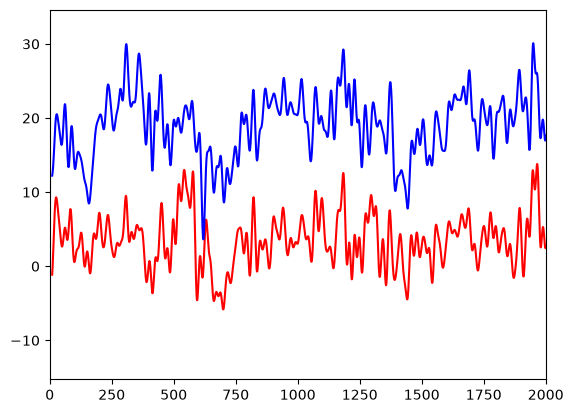

In [7]:
plt.plot(TRANS_EKMAN.values,color = "red")
plt.plot(TRANS_FC.values,color = "blue")
# plt.plot(deseasonalized_EKMAN.values,color = "red")
# plt.plot(deseasonalized_FC.values,color = "blue")
plt.xlim(0,2000)

(0.0, 2000.0)

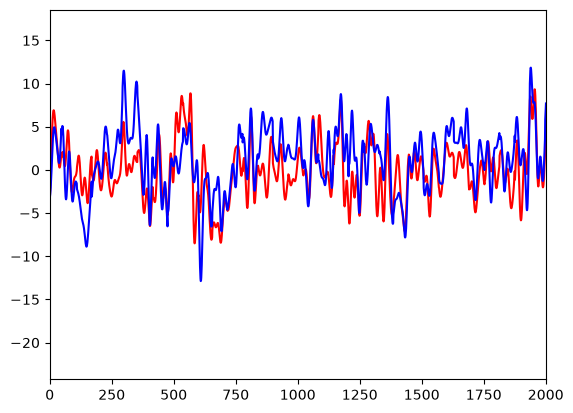

In [8]:
plt.plot(deseasonalized_EKMAN.values,color = "red")
plt.plot(deseasonalized_FC.values,color = "blue")
plt.xlim(0,2000)

In [9]:
lags, cc = correlation.cross_correlation(deseasonalized_EKMAN, deseasonalized_FC)
lag = lags[cc.argmax()] * 0.5
print(f"The Ekman component leads the Florida Current by {-lag} days")

The Ekman component leads the Florida Current by 0.5 days


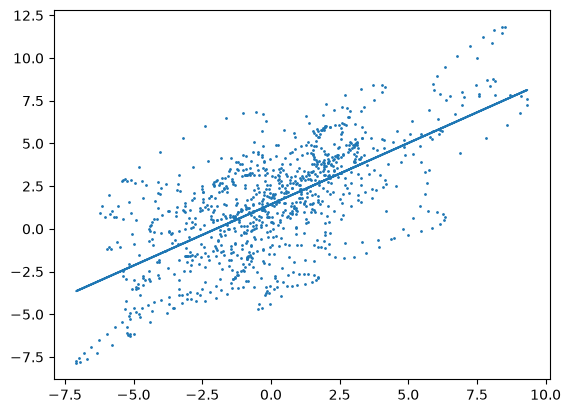

In [10]:
plt.scatter(deseasonalized_EKMAN[1000:2000], deseasonalized_FC[1001:2001], s = 1)
lag_trend = linregress(deseasonalized_EKMAN[1000:2000], deseasonalized_FC[1001:2001])
plt.plot(deseasonalized_EKMAN[1000:2000], lag_trend.intercept + lag_trend.slope * deseasonalized_EKMAN[1000:2000])

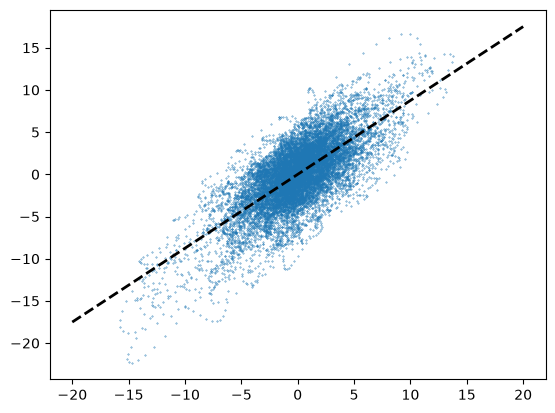

In [11]:
plt.scatter(deseasonalized_EKMAN[:-1], deseasonalized_FC[1:], s = 0.1)
lag_trend = linregress(deseasonalized_EKMAN[:-1], deseasonalized_FC[1:])
plt.plot(
    np.linspace(-20, 20, 100), 
    lag_trend.intercept + lag_trend.slope * np.linspace(-20, 20, 100), 
    lw = 2, 
    ls = "--",
    color = "k"
)

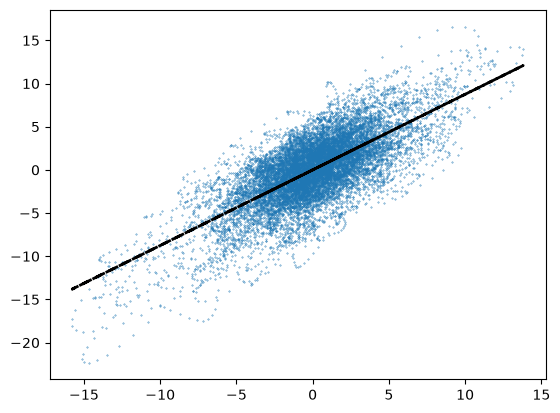

In [12]:
plt.scatter(deseasonalized_EKMAN[:-1], deseasonalized_FC[1:], s = 0.1)
lag_trend = linregress(deseasonalized_EKMAN[:-1], deseasonalized_FC[1:])
plt.plot(
    deseasonalized_EKMAN[:-1], 
    lag_trend.intercept + lag_trend.slope * deseasonalized_EKMAN[:-1], 
    lw = 2, 
    ls = "--",
    color = "k"
)